In [1]:
# Add project root (the folder that contains "src/") to sys.path
import sys
import time
from pathlib import Path

def add_project_root(marker_dir="src", max_hops=5):
    p = Path.cwd().resolve()
    for _ in range(max_hops):
        if (p / marker_dir).exists():
            sys.path.insert(0, str(p))
            print(f"[OK] Added to sys.path: {p}")
            return
        p = p.parent
    raise RuntimeError(f"Could not find '{marker_dir}' within {max_hops} parents from {Path.cwd()}")

add_project_root()  

[OK] Added to sys.path: D:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation


In [2]:
import os, numpy as np, matplotlib.pyplot as plt
from matplotlib import patheffects
from PIL import Image

from src.data.preprocessing import _iso_resize_and_pad
from src.retina_biomarkers.od_seg import (
    load_refuge_segformer, infer_label_map, extract_disc_mask_safe,
    center_and_pd_with_bounds
)

# ---------- IO helpers ----------
def _read_rgb(path):
    return np.array(Image.open(path).convert("RGB"), dtype=np.uint8)

def _read_fov_mask(path, ref_shape):
    if (path is None) or (not os.path.exists(path)):
        return np.ones(ref_shape[:2], dtype=bool)
    m = Image.open(path)
    if m.mode != "L":
        m = m.convert("L")
    m = np.array(m, dtype=np.uint8)
    if m.shape != ref_shape[:2]:
        m = np.array(Image.fromarray(m).resize((ref_shape[1], ref_shape[0]), resample=Image.NEAREST))
    return m > 0

def find_fovea_xy_from_cyan(fovea_img_path, ref_shape=None, tol=40):
    f = _read_rgb(fovea_img_path)
    Hf, Wf = f.shape[:2]
    R, G, B = f[...,0], f[...,1], f[...,2]
    mask = (R <= tol) & (G >= 255 - tol) & (B >= 240 - tol)
    if not mask.any():
        mask = (R < 80) & (G > 170) & (B > 170)
    ys, xs = np.nonzero(mask)
    if ys.size == 0:
        raise ValueError(f"No cyan dot found in {fovea_img_path}")
    fy, fx = float(ys.mean()), float(xs.mean())
    if ref_shape and (ref_shape[0] != Hf or ref_shape[1] != Wf):
        fy *= ref_shape[0] / Hf
        fx *= ref_shape[1] / Wf
    return fx, fy  # (x, y)

# ---------- OD-only (your model) ----------
IMAGE_SIZE      = 512
R_FRAC          = (0.08, 0.16)
CUP_DILATE_FRAC = 0.12

processor, od_model, od_device = load_refuge_segformer()

def od_from_image_path(color_path):
    fundus_pil = Image.open(color_path).convert("RGB")
    rgb_iso = _iso_resize_and_pad(np.array(fundus_pil), target=IMAGE_SIZE, pad_value=0).astype(np.uint8)
    H, W = rgb_iso.shape[:2]
    pred_map = infer_label_map(rgb_iso, processor, od_model, device=od_device)
    disc_mask = extract_disc_mask_safe(pred_map, od_model.config.id2label, img_shape=rgb_iso.shape,
                                       cup_dilate_frac=CUP_DILATE_FRAC)
    center_yx, PD_raw, PD_px = center_and_pd_with_bounds(
        disc_mask, rgb_iso.shape, r_frac=R_FRAC,
        allow_fallback=True, fallback_center_yx=(H/2.0, W/2.0),
        fallback_PD_px=0.20 * min(H, W)
    )
    return rgb_iso, disc_mask, (float(center_yx[0]), float(center_yx[1])), float(PD_px)

# ---------- ISNT quadrants (no ring clipping) ----------
def isnt_quadrants_masks(shape_hw, disc_yx, *, fovea_yx=None, laterality=None, style="x", fov=None):
    """
    Build four *exclusive* ISNT quadrant masks over the whole image (optionally restricted by FOV).
    style:
      - 'plus': boundaries = disc→fovea axis and its perpendicular (a + sign).
      - 'x'   : boundaries rotated ±45° from disc→fovea (an X, like your figure).
    """
    H, W = shape_hw
    cy, cx = disc_yx

    # Unit basis: v = Temporal direction, p = perpendicular (Superior direction when 'up')
    if fovea_yx is not None:
        fy, fx = fovea_yx
        v = np.array([fx - cx, fy - cy], float)  # (x,y)
        n = np.linalg.norm(v); v = v / (n + 1e-9) if n > 0 else np.array([1.0, 0.0])
    else:
        if laterality not in ("left", "right"):
            raise ValueError("Provide fovea_yx or laterality in {'left','right'}.")
        v = np.array([1.0, 0.0]) if laterality == "left" else np.array([-1.0, 0.0])
    p = np.array([-v[1], v[0]])  # rotate +90°

    yy, xx = np.mgrid[0:H, 0:W]
    relx, rely = (xx - cx).astype(float), (yy - cy).astype(float)

    # coordinates in (v, p) basis
    a = relx*v[0] + rely*v[1]   # along Temporal (+) / Nasal (-)
    b = relx*p[0] + rely*p[1]   # along Inferior (+) / Superior (-)   (image y increases downward)

    # Optional FOV
    base = np.ones((H, W), bool) if fov is None else fov.astype(bool)

    masks = {}

    if style == "plus":
        # Four *exclusive* quadrants via sign of (a,b)
        masks["T"] = (a >= 0) & (np.abs(a) >= np.abs(b)) & base
        masks["N"] = (a <  0) & (np.abs(a) >  np.abs(b))  & base
        masks["I"] = (b >= 0) & (np.abs(b) >  np.abs(a))  & base
        masks["S"] = (b <  0) & (np.abs(b) >= np.abs(a))  & base

    else:  # style == "x" — split by angle with 45° boundaries (your diagram)
        # angle in rotated frame: theta = atan2(b, a) in (-pi, pi]
        theta = np.arctan2(b, a)
        # sectors of width 90° centered on each cardinal direction
        # Temporal:  (-45°, +45°)
        masks["T"] = (theta > -np.pi/4) & (theta <=  np.pi/4)   & base
        # Inferior:  (+45°, +135°)
        masks["I"] = (theta >  np.pi/4) & (theta <=  3*np.pi/4) & base
        # Nasal:     (+135°, -135°]  (wrap-around)
        masks["N"] = (theta >  3*np.pi/4) | (theta <= -3*np.pi/4)
        masks["N"] &= base
        # Superior:  (-135°, -45°]
        masks["S"] = (theta > -3*np.pi/4) & (theta <= -np.pi/4) & base

    return masks  # dict with keys 'I','S','N','T'

# ---------- Drawing ----------
def _label(ax, x, y, txt, fs=12):
    pe = [patheffects.withStroke(linewidth=3, foreground='black', alpha=0.6)]
    t = ax.text(x, y, txt, color="white", fontsize=fs, ha="center", va="center")
    t.set_path_effects(pe)

def draw_isnt_quadrants(ax, img_rgb, masks_dict, disc_yx, fovea_yx=None, style="x"):
    ax.imshow(img_rgb); ax.axis("off")

    colors = {"I": (0.10, 0.70, 1.00, 0.22),   # cyan
              "S": (1.00, 0.25, 0.65, 0.22),   # magenta
              "N": (1.00, 0.90, 0.10, 0.22),   # yellow
              "T": (0.10, 0.85, 0.35, 0.22)}   # green

    overlay = np.zeros((*img_rgb.shape[:2], 4), float)
    for k, m in masks_dict.items():
        overlay[m, :3] = colors[k][:3]
        overlay[m, 3]  = colors[k][3]
    ax.imshow(overlay)

    cy, cx = disc_yx
    # Draw boundaries
    if fovea_yx is not None:
        fy, fx = fovea_yx
        v = np.array([fx - cx, fy - cy], float); v /= (np.linalg.norm(v) + 1e-9)
    else:
        v = np.array([1.0, 0.0])
    p = np.array([-v[1], v[0]])
    H, W = img_rgb.shape[:2]; L = max(H, W)

    if style == "plus":
        dirs = [v, -v, p, -p]
    else:
        # 45° rotated boundaries
        d1 = ( v + p) / np.sqrt(2)
        d2 = (-v + p) / np.sqrt(2)
        d3 = (-v - p) / np.sqrt(2)
        d4 = ( v - p) / np.sqrt(2)
        dirs = [d1, d2, d3, d4]

    for d in dirs:
        ax.plot([cx - L*d[0], cx + L*d[0]], [cy - L*d[1], cy + L*d[1]], color="white", lw=1)

    # markers
    ax.scatter([cx], [cy], s=50, c="yellow", marker="x", linewidths=1.5)
    if fovea_yx is not None:
        fy, fx = fovea_yx
        ax.scatter([fx], [fy], s=50, c="cyan", marker="x", linewidths=1.5)

# ---------- Runner ----------
def show_isnt_quadrants_od(group_name, img_paths, fov_paths, fovea_paths, lateralities,
                           style="x", max_cols=3):
    assert len(img_paths) == len(fovea_paths) == len(lateralities)
    if fov_paths is None:
        fov_paths = [None]*len(img_paths)
    elif len(fov_paths) != len(img_paths):
        fov_paths = (fov_paths + [None]*len(img_paths))[:len(img_paths)]

    n = len(img_paths); cols = min(max_cols, n); rows = int(np.ceil(n/cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5.3*cols, 5.4*rows))
    axes = np.array(axes).reshape(rows, cols)
    fig.suptitle(f"{group_name}: ISNT quadrants (no ring clipping) — style={style}", y=0.98, fontsize=14)

    for i, (p_img, p_fov, p_fovep, lat) in enumerate(zip(img_paths, fov_paths, fovea_paths, lateralities)):
        ax = axes.flat[i]
        rgb_iso, disc_mask, center_yx, PD_px = od_from_image_path(p_img)
        fov_mask = _read_fov_mask(p_fov, rgb_iso.shape)
        fx, fy = find_fovea_xy_from_cyan(p_fovep, ref_shape=rgb_iso.shape[:2])
        fovea_yx = (fy, fx)

        masks = isnt_quadrants_masks(rgb_iso.shape[:2], center_yx,
                                     fovea_yx=fovea_yx, laterality=lat,
                                     style=style, fov=fov_mask)

        ax.set_title(f"{os.path.basename(p_img)} • {lat.capitalize()}", fontsize=10)
        draw_isnt_quadrants(ax, rgb_iso, masks, center_yx, fovea_yx=fovea_yx, style=style)

        # quadrant labels near the four sides
        cy, cx = center_yx; H, W = rgb_iso.shape[:2]
        _label(ax, x=cx,       y=cy - 0.28*H, txt="Superior")
        _label(ax, x=cx,       y=cy + 0.28*H, txt="Inferior")
        _label(ax, x=cx + 0.28*W, y=cy,       txt="Temporal")
        _label(ax, x=cx - 0.28*W, y=cy,       txt="Nasal")

    for j in range(n, rows*cols):
        axes.flat[j].axis("off")

    plt.tight_layout(); plt.show()


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
d:\Data\Projects\Thesis\Adaptive-Hierarchical-Feature-Modulation-U-Net-Model-for-Retinal-Vessel-Segmentation\myenv\Lib\site-packages\transformers\image_processing_base.py:417: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'reduce_labels'
  image_processor = cls(**image_processor_dict)


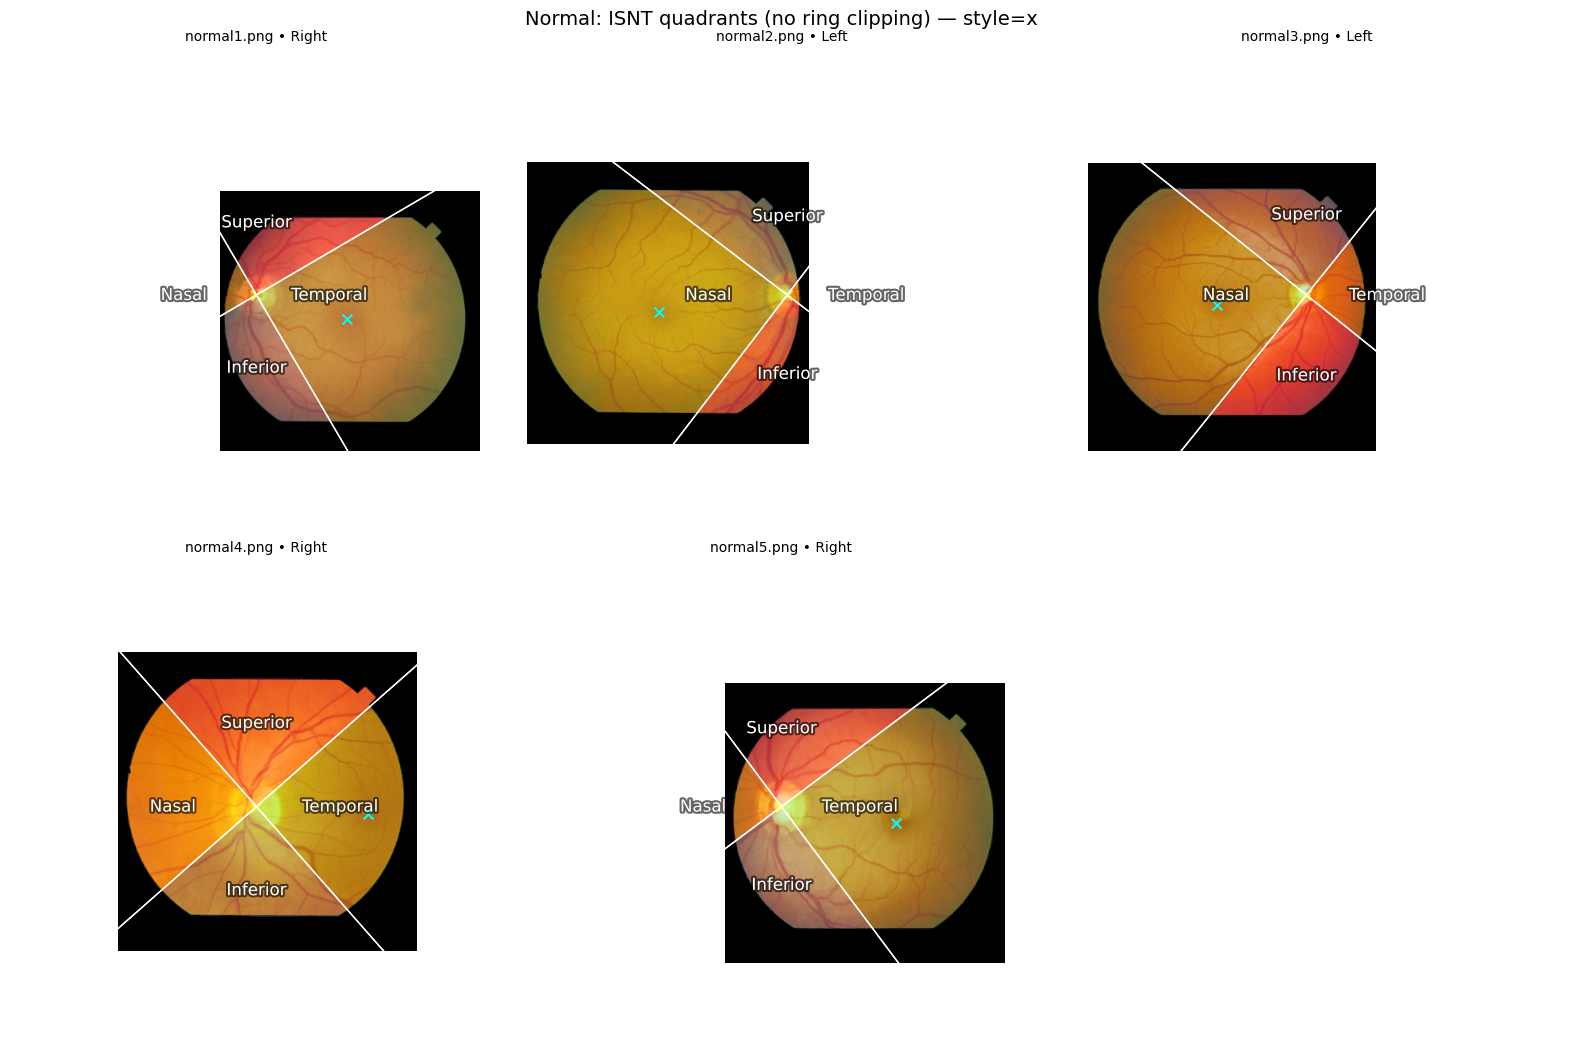

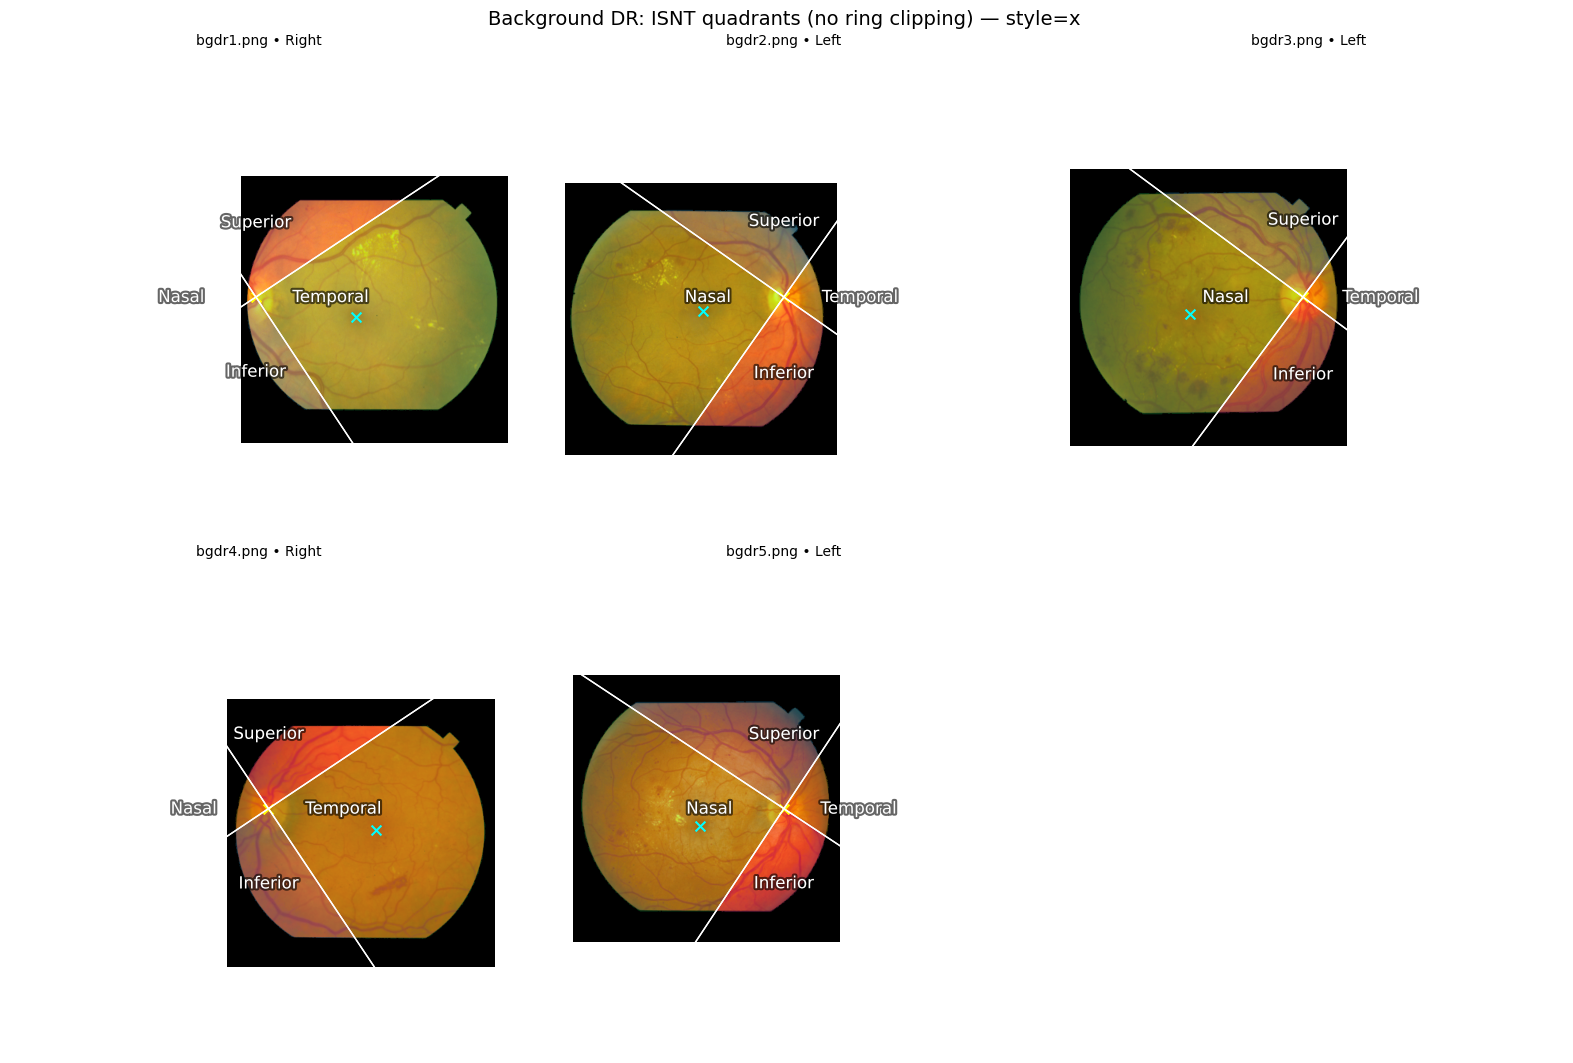

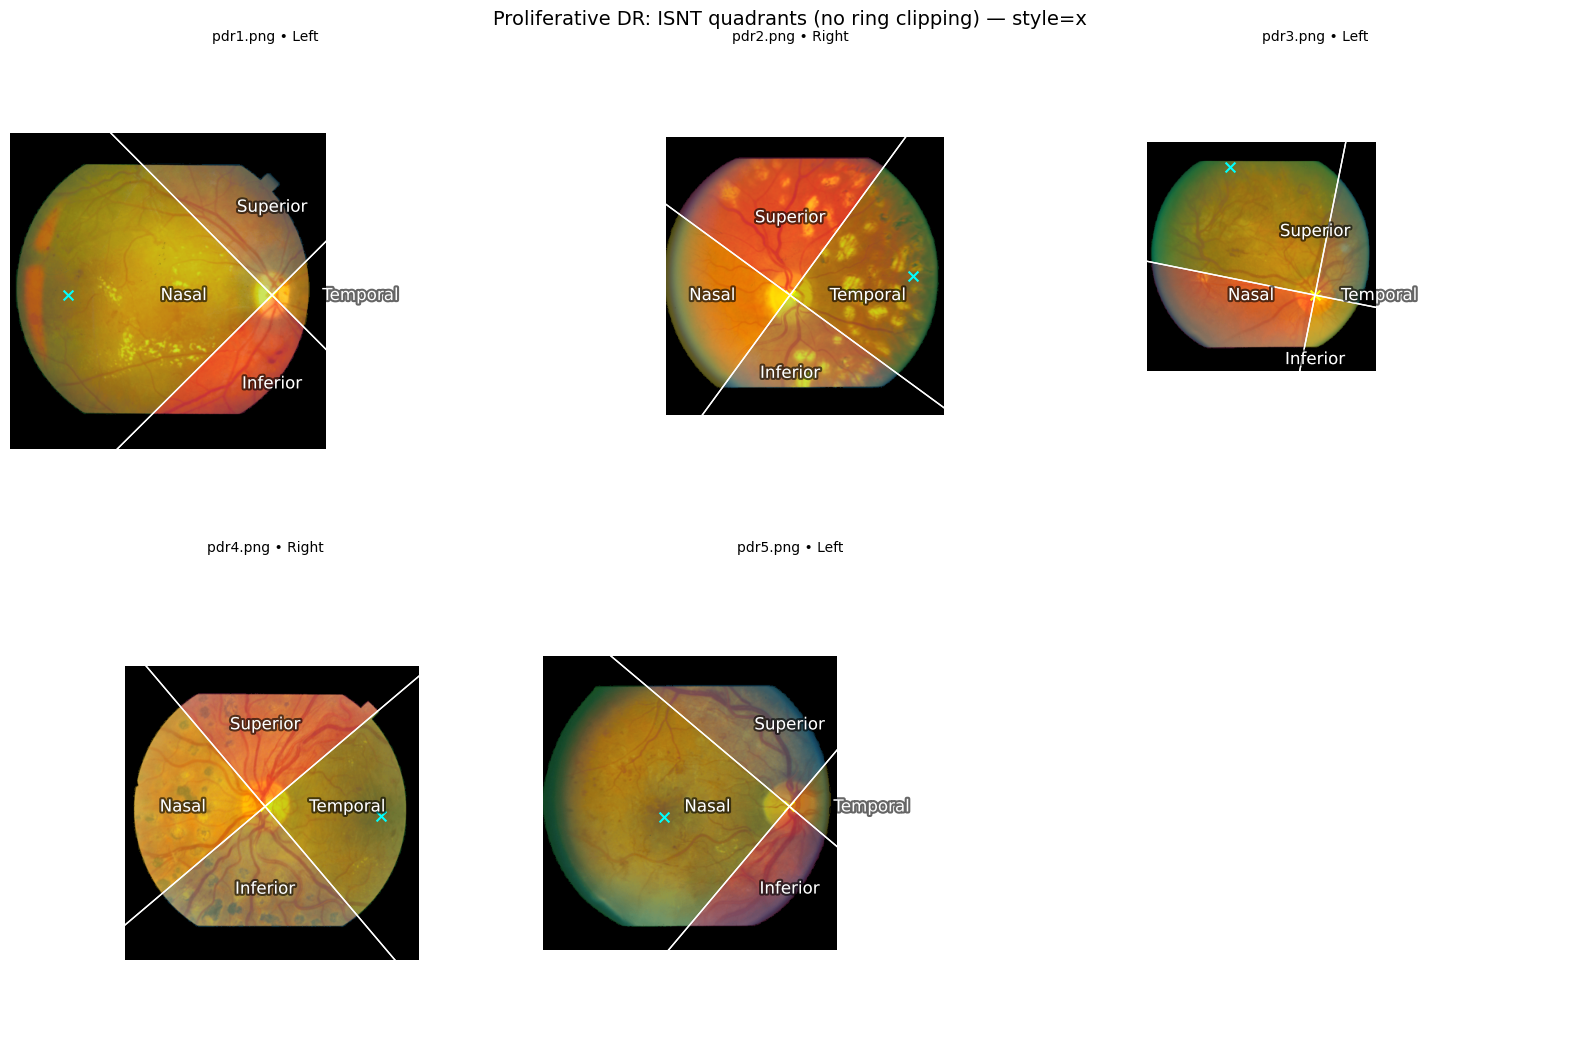

In [3]:
# --- Your paths (as provided) ---
normal_paths = [
    "../../data/raw/DR_sampleset/normal1.png", # right
    "../../data/raw/DR_sampleset/normal2.png", # left
    "../../data/raw/DR_sampleset/normal3.png", # left
    "../../data/raw/DR_sampleset/normal4.png", # right
    "../../data/raw/DR_sampleset/normal5.png", # right
]
bgdr_paths = [
    "../../data/raw/DR_sampleset/bgdr1.png", # right
    "../../data/raw/DR_sampleset/bgdr2.png", # left
    "../../data/raw/DR_sampleset/bgdr3.png", # left
    "../../data/raw/DR_sampleset/bgdr4.png", # right
    "../../data/raw/DR_sampleset/bgdr5.png", # left
]
pdr_paths = [
    "../../data/raw/DR_sampleset/pdr1.png", # left
    "../../data/raw/DR_sampleset/pdr2.png", # right 
    "../../data/raw/DR_sampleset/pdr3.png", # left
    "../../data/raw/DR_sampleset/pdr4.png", # right  
    "../../data/raw/DR_sampleset/pdr5.png", # left
] 

normal_paths_fovea = [
    "../../data/raw/DR_sampleset/normal1_fovea.png",
    "../../data/raw/DR_sampleset/normal2_fovea.png",
    "../../data/raw/DR_sampleset/normal3_fovea.png",
    "../../data/raw/DR_sampleset/normal4_fovea.png",
    "../../data/raw/DR_sampleset/normal5_fovea.png",
]
bgdr_paths_fovea = [
    "../../data/raw/DR_sampleset/bgdr1_fovea.png",
    "../../data/raw/DR_sampleset/bgdr2_fovea.png",
    "../../data/raw/DR_sampleset/bgdr3_fovea.png",
    "../../data/raw/DR_sampleset/bgdr4_fovea.png",
    "../../data/raw/DR_sampleset/bgdr5_fovea.png",
]
pdr_paths_fovea = [
    "../../data/raw/DR_sampleset/pdr1_fovea.png",
    "../../data/raw/DR_sampleset/pdr2_fovea.png",
    "../../data/raw/DR_sampleset/pdr3_fovea.png",
    "../../data/raw/DR_sampleset/pdr4_fovea.png",
    "../../data/raw/DR_sampleset/pdr5_fovea.png",
]


normal_paths_fov = [
    "../../data/raw/DR_sampleset/normal1_fov.png",
    "../../data/raw/DR_sampleset/normal2_fov.png",
    "../../data/raw/DR_sampleset/normal3_fov.png",
    "../../data/raw/DR_sampleset/normal4_fov.png",
    "../../data/raw/DR_sampleset/normal5_fov.png",
]
bgdr_paths_fov = [
    "../../data/raw/DR_sampleset/bgdr1_fov.png",
    "../../data/raw/DR_sampleset/bgdr2_fov.png",
    "../../data/raw/DR_sampleset/bgdr3_fov.png",
    "../../data/raw/DR_sampleset/bgdr4_fov.png",
    "../../data/raw/DR_sampleset/bgdr5_fov.png",
]
pdr_paths_fov = [
    "../../data/raw/DR_sampleset/pdr1_fov.png",
    "../../data/raw/DR_sampleset/pdr2_fov.png",
    "../../data/raw/DR_sampleset/pdr3_fov.png",
    "../../data/raw/DR_sampleset/pdr4_fov.png",
    "../../data/raw/DR_sampleset/pdr5_fov.png",
]


# Laterality lists:
normal_lat = ["right", "left", "left", "right", "right"]
bgdr_lat   = ["right", "left", "left", "right", "left"]
pdr_lat    = ["left",  "right","left",  "right","left"]


show_isnt_quadrants_od("Normal",           normal_paths, normal_paths_fov, normal_paths_fovea, normal_lat, style="x")
show_isnt_quadrants_od("Background DR",    bgdr_paths,   bgdr_paths_fov,   bgdr_paths_fovea,   bgdr_lat,   style="x")
show_isnt_quadrants_od("Proliferative DR", pdr_paths,    pdr_paths_fov,    pdr_paths_fovea,    pdr_lat,    style="x")

